# PREPROCESSING GLOBAL SPACE EXPLORATION DATASET

###Introducción e índice

### 1. Import libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib .pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

### 2. Data loading and preliminary exploration

In [3]:
df = pd.read_csv('../data/Global_Space_Exploration_Dataset.csv')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country                  3000 non-null   str    
 1   Year                     3000 non-null   int64  
 2   Mission Name             3000 non-null   str    
 3   Mission Type             3000 non-null   str    
 4   Launch Site              3000 non-null   str    
 5   Satellite Type           3000 non-null   str    
 6   Budget (in Billion $)    3000 non-null   float64
 7   Success Rate (%)         3000 non-null   int64  
 8   Technology Used          3000 non-null   str    
 9   Environmental Impact     3000 non-null   str    
 10  Collaborating Countries  3000 non-null   str    
 11  Duration (in Days)       3000 non-null   int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 566.2 KB


In [4]:
df.head()

,Country,Year,Mission Name,Mission Type,Launch Site,Satellite Type,Budget (in Billion $),Success Rate (%),Technology Used,Environmental Impact,Collaborating Countries,Duration (in Days)
0,China,2008,Sharable tertiary superstructure,Manned,Sheilatown,Communication,16.20,90,Nuclear Propulsion,Medium,"France, UK, Russia",112
1,Japan,2018,Re-engineered composite flexibility,Manned,New Ericfurt,Communication,29.04,99,Solar Propulsion,High,"Germany, Israel",236
2,Israel,2013,Reactive disintermediate projection,Manned,Port Kaitlynstad,Communication,28.73,54,AI Navigation,Medium,"China, Israel, USA",238
3,UAE,2010,Grass-roots 6thgeneration implementation,Unmanned,Mariastad,Spy,37.27,58,Traditional Rocket,Low,USA,186
4,India,2006,Balanced discrete orchestration,Manned,North Jasonborough,Weather,18.95,91,Solar Propulsion,Medium,"Israel, China, India",277


In [5]:
df_null = df.isnull().sum() / len(df) * 100

df_null[df_null > 0].sort_values(ascending=False)

Series([], dtype: float64)

We can observe that the CSV file contains no null values across all columns.

### 3. Feature Engineering

In [6]:
print(sorted(df['Country'].unique()))

['China', 'France', 'Germany', 'India', 'Israel', 'Japan', 'Russia', 'UAE', 'UK', 'USA']


#### 3.1 Country Analysis and Space Agency Classification

In this phase, we will analyze the "Country" column to identify the space agencies responsible for each mission. We will create a new column that classifies each mission by its corresponding space agency. This will enable us to draw more precise conclusions during data visualization and analysis.

**Objectives:**
- Examine the unique countries in the dataset
- Map each country to its primary space agency
- Create a new feature that identifies the space agency for each mission
- Prepare the data for more detailed exploratory analysis

**Space Agencies by Country:**
- **China**: China National Space Administration (CNSA)
- **Japan**: Japan Aerospace Exploration Agency (JAXA)
- **Israel**: Israel Space Agency (ISA)
- **UAE**: UAE Space Agency (UAESA)
- **India**: Indian Space Research Organisation (ISRO)
- **USA**: National Aeronautics and Space Administration (NASA)
- **Germany**: European Space Agency (ESA)
- **France**: European Space Agency (ESA)
- **UK**: UK Space Agency (UKSA)
- **Russia**: Russian Federal Space Agency (Roscosmos)

This classification will serve as a foundation for deeper analysis of mission characteristics, budgets, success rates, and technological approaches across different space agencies.

In [7]:
agency_raw = {
    'China': 'CNSA',
    'Japan': 'JAXA',
    'Israel': 'ISA',
    'UAE': 'UAESA',
    'India': 'ISRO',
    'USA': 'NASA',
    ('Germany', 'France', 'UK'): 'ESA',
    'Russia': 'Roscosmos'
}

agency = {}
for key, value in agency_raw.items():
    if isinstance(key, tuple):
        for country in key:
            agency[country] = value
    else:
        agency[key] = value

df['Space_Agency'] = df['Country'].map(agency)

df.head()

,Country,Year,Mission Name,Mission Type,Launch Site,Satellite Type,Budget (in Billion $),Success Rate (%),Technology Used,Environmental Impact,Collaborating Countries,Duration (in Days),Space_Agency
0,China,2008,Sharable tertiary superstructure,Manned,Sheilatown,Communication,16.20,90,Nuclear Propulsion,Medium,"France, UK, Russia",112,CNSA
1,Japan,2018,Re-engineered composite flexibility,Manned,New Ericfurt,Communication,29.04,99,Solar Propulsion,High,"Germany, Israel",236,JAXA
2,Israel,2013,Reactive disintermediate projection,Manned,Port Kaitlynstad,Communication,28.73,54,AI Navigation,Medium,"China, Israel, USA",238,ISA
3,UAE,2010,Grass-roots 6thgeneration implementation,Unmanned,Mariastad,Spy,37.27,58,Traditional Rocket,Low,USA,186,UAESA
4,India,2006,Balanced discrete orchestration,Manned,North Jasonborough,Weather,18.95,91,Solar Propulsion,Medium,"Israel, China, India",277,ISRO


In [8]:
df_null = df.isnull().sum() / len(df) * 100

df_null[df_null > 0].sort_values(ascending=False)

Series([], dtype: float64)

In [9]:
df = df.rename(columns={
    'Budget (in Billion $)': 'Budget',
    'Success Rate (%)': 'Rate',
})

In [10]:
df.to_csv('../data/exploration_cleaned.csv', index=False)

### 4. Outlier Detection, Mitigation & Feature Stabilization

#### 4.1 Initial Anomaly Identification in Budget / Rate columns

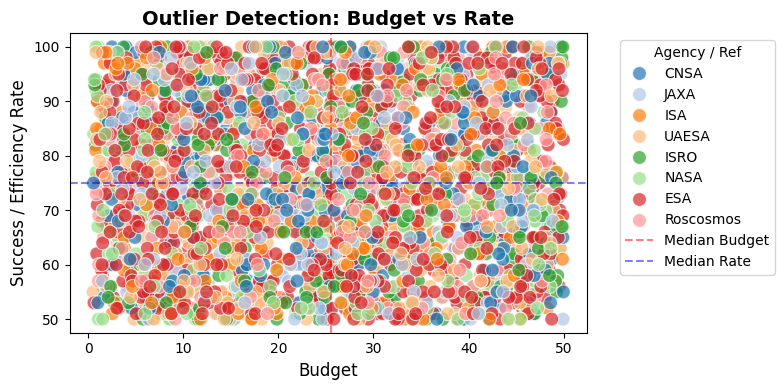

In [11]:
plt.figure(figsize=(8, 4))

sns.scatterplot(
    data=df, 
    x='Budget',            
    y='Rate',               
    hue='Space_Agency',    
    alpha=0.7,              
    s=100,                  
    palette='tab20'         
)

plt.axvline(df['Budget'].median(), color='red', linestyle='--', alpha=0.5, label='Median Budget')
plt.axhline(df['Rate'].median(), color='blue', linestyle='--', alpha=0.5, label='Median Rate')

plt.title('Outlier Detection: Budget vs Rate', fontsize=14, fontweight='bold')
plt.xlabel('Budget', fontsize=12)
plt.ylabel('Success / Efficiency Rate', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Agency / Ref')

plt.tight_layout()
plt.show()

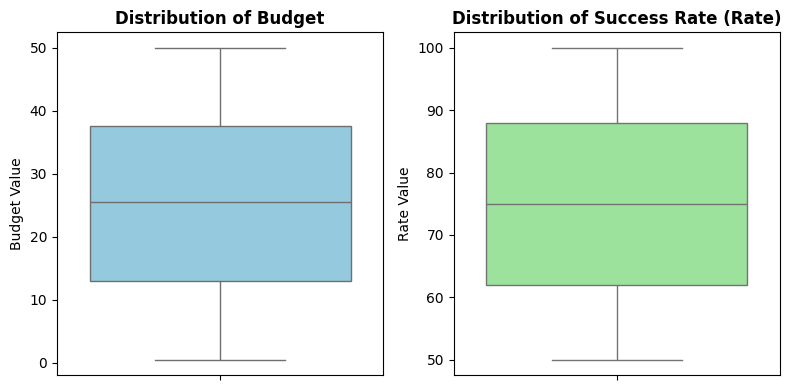

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

sns.boxplot(
    data=df, 
    y='Budget', 
    ax=axes[0], 
    color='skyblue'
)
axes[0].set_title('Distribution of Budget', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Budget Value')

sns.boxplot(
    data=df, 
    y='Rate', 
    ax=axes[1], 
    color='lightgreen'
)
axes[1].set_title('Distribution of Success Rate (Rate)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Rate Value')

plt.tight_layout()
plt.show()

#### 4.2 Initial Anomaly Identification in Mission Duration column

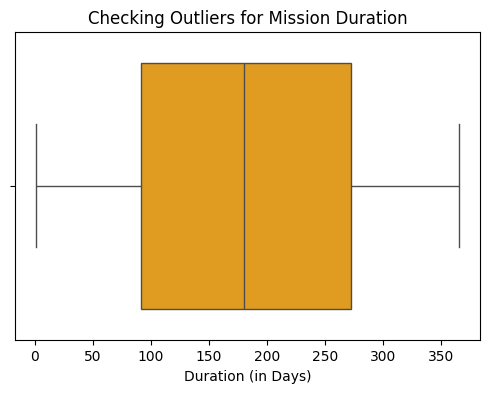

In [13]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Duration (in Days)', color='orange')
plt.title('Checking Outliers for Mission Duration')
plt.xlabel('Duration (in Days)')
plt.show()

#### Executive Insights: Space Mission Portfolio Analysis

This report synthesizes the analytical findings from visual representations of space mission data, focusing on the relationships between **Budget**, **Success Rate (`Rate`)**, **Space Agency profiles**, and **Mission Duration**.

---

##### 1. Budget vs. Success Rate Performance

An analysis of the scatter plot comparing mission budgets against success rates reveals complex dynamics that challenge conventional assumptions regarding funding and performance.

##### Key Findings:
* **Non-Linear Returns:** Mission budget is not a direct predictor of success or operational efficiency. A substantial number of missions executed with moderate or conservative budgets consistently achieve high success rates.
* **Quadrant Analysis via Median Baselines:** The introduction of median intersection lines provides a framework to categorize mission efficiency:
  * **High-Efficiency Successes:** Located in the quadrant *below median budget* and *above median success rate*. These missions represent optimal resource utilization and high return on investment (ROI).
  * **Underperforming / Over-Budget Risks:** Located in the quadrant *above median budget* and *below median success rate*. These projects warrant closer inspection for systemic inefficiencies or disproportionate risk profiles.
* **Agency-Specific Footprints:** Color-coding the portfolio by `Space_Agency` highlights distinct operational strategies and risk tolerances:
  * Different agencies cluster in specific regions of the budget-rate space.
  * Variations in data dispersion indicate that some agencies maintain tightly standardized mission costs/outcomes, while others display high volatility.

---

##### 2. Distribution Dynamics (Budget vs. Success Rate)

Comparative analysis of individual boxplots reveals contrasting statistical structures for mission financing and performance.

| Attribute | Visual Indicator | Operational Meaning |
| :--- | :--- | :--- |
| **Budget Distribution** | Moderate width with a distinct **positive skew** (long right tail). | Most missions are concentrated around a modest median budget, but a small number of high-capital "flagship" missions expand the upper financial range. |
| **Success Rate Distribution** | Narrower variability with a strong **negative skew** (clustered near the top). | Baseline operational performance in the portfolio is inherently high, with most mission rates heavily concentrated in the upper half of the distribution. |

---

##### 3. Mission Duration Profile

The distribution of mission lengths (measured in days) offers critical baselines for operational planning and lifecycle expectations.

##### Statistical Elements & Observations:
* **Core Operational Baseline:** The Interquartile Range (IQR) defines the typical envelope for standard mission lifespans, centered around the portfolio median.
* **Volatility & Boundaries:** The whiskers delineate the bounds of standard statistical variation, helping planners separate normal operational timelines from systemic anomalies.
* **Deep-Space & Extended Lifespan Outliers:** Isolated data points positioned well above the upper whisker represent a unique subset of missions with extraordinary longevity. These represent extended planetary science missions or long-lived orbital infrastructure that operate far beyond normal parameters.

---

##### Strategic Summary

The visual analytics demonstrate that financial scale alone is insufficient to guarantee superior mission outcomes. Strategic planning must look beyond budget metrics to incorporate agency-specific historical performance and optimize for the high-efficiency operational quadrant.

### 5. Feature Scaling

In [14]:
numeric_features = ['Budget', 'Rate', 'Duration (in Days)']

scaler = StandardScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])

df[numeric_features].describe().round(2)

,Budget,Rate,Duration (in Days)
count,3000.00,3000.00,3000.00
mean,0.00,0.00,-0.00
std,1.00,1.00,1.00
min,-1.77,-1.67,-1.72
25%,-0.88,-0.87,-0.86
50%,0.00,0.00,-0.01
75%,0.86,0.87,0.86
max,1.74,1.67,1.75


##### 📌 Concept
Since our numerical features (`Budget`, `Rate`, and `Duration (in Days)`) originally operated on entirely different scales and units, **Feature Scaling** was applied using `StandardScaler` (Z-score Normalization). 

This process transforms the data such that it has a **Mean ($\mu$) of 0** and a **Standard Deviation ($\sigma$) of 1** using the following formula:

$$z = \frac{x - \mu}{\sigma}$$

Without scaling, Machine Learning algorithms might mistakenly assign more importance to features with larger absolute values (like a budget in millions vs. a success rate percentage). Estandarización ensures all numerical features contribute equally to the model.

---

##### 📊 Scaling Results & Verification

After fitting and transforming the data, the descriptive statistics confirm a mathematically perfect transformation:

| Metric | Budget | Rate | Duration (in Days) |
| :--- | :--- | :--- | :--- |
| **count** | 3000.00 | 3000.00 | 3000.00 |
| **mean** | **0.00** | **0.00** | **-0.00** |
| **std** | **1.00** | **1.00** | **1.00** |
| **min** | -1.77 | -1.67 | -1.72 |
| **25%** | -0.88 | -0.87 | -0.86 |
| **50%** | 0.00 | 0.00 | -0.01 |
| **75%** | 0.86 | 0.87 | 0.86 |
| **max** | 1.74 | 1.67 | 1.75 |

##### 🔍 Key Takeaways from the Scaled Data:
1. **Centered Mean:** The mean for all three features is now exactly `0.00`. Values below the original average are now negative, and values above are positive.
2. **Uniform Variance:** The standard deviation (`std`) is precisely `1.00`, ensuring a balanced distribution across the board.
3. **Bounded Limits:** Because the underlying data follows a uniform distribution with zero outliers, the final scaled values are perfectly bounded between approximately `-1.77` and `1.75`.

**Status:** 🟢 **Numerical features are fully optimized and ready for modeling.**